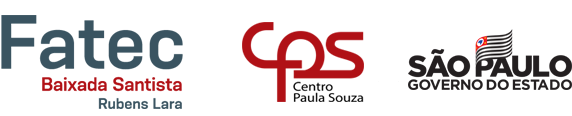
# PROJETO SEMESTRAL de PII DETECTION (do português, Detecção de Informações de Identificação Pessoal)
Tipo: Pesquisa e Avaliação de Modelos

Disciplina: Machine Learning II

Grupo: Enzo Farias de Moraes, Luann Gagliardi e Paulo Henrique Tavares Delfino de Andrade

### Objetivo Geral
Avaliar e comparar de forma rigorosa diferentes arquiteturas de modelos e abordagens baseadas em regras para a identificação e anonimização de dados sensíveis em textos. O foco central é validar a aplicabilidade destas soluções, garantindo a conformidade com a LGDP.

### Objetivos Específicos
* Implementar uma arquitetura de software Orientada a Objetos para padronizar e facilitar o consumo de diferentes modelos fundacionais;
* Avaliar o desempenho de modelos pré-treinados (RoBERTa, DeBERTa, XLM-RoBERTa) em um benchmark utilizando um dataset sintético bilíngue (inglês e português);
* Desenvolver uma métrica de avaliação customizada (F2-Score) que penaliza severamente os Falsos Negativos, refletindo o alto risco que o vazamento de dados representa para o negócio;
* Validar a utilidade prática dos modelos em um documento comercial do mercado automotivo (contrato de compra e venda) utilizando técnicas de mesclagem de recortes de texto;
* Propor e construir um modelo híbrido (Ensemble) que combine a flexibilidade semântica da inteligência artificial com a precisão absoluta de expressões regulares (Regex).

### Metodologia
O projeto inicia com o carregamento de instâncias de modelos via biblioteca Transformers e a obtenção de dados via biblioteca Datasets. A avaliação primária ocorre em um ambiente isolado (inferência zero-shot) com amostras aleatórias de textos bilíngues. Em seguida, o pipeline é submetido a um teste de estresse em um cenário real (texto de contrato). Por fim, é construída a solução de Ensemble que sobrepõe os resultados da IA e de Regex para garantir que nenhum padrão brasileiro estruturado, como CPF ou CNPJ, seja ignorado.

In [ ]:
!pip install transformers datasets pandas matplotlib -q

## 1. Importação de Bibliotecas e Arquitetura do Sistema

Para garantir a qualidade, manutenibilidade e escalabilidade do código, adotamos o paradigma da Programação Orientada a Objetos (POO) em conjunto com o princípio do Polimorfismo.

Aplicações de Engenharia de Software no Pipeline:
* Classe Abstrata (BasePIIDetector): Utilizando o módulo nativo abc do Python, criamos um contrato rígido. Qualquer nova arquitetura a ser inserida no sistema precisa implementar um método de chamada padronizado e possuir um nome, permitindo que o código de avaliação rode sem precisar saber os detalhes do modelo subjacente.
* Extração Dinâmica de Entidades: Evitamos criar listas manuais engessadas sobre o que cada modelo detecta. O código consulta o AutoConfig dos pesos originais e descobre sozinho quais são as tags de privacidade que aquela IA específica consegue ler.
* Controle de Variáveis de Ambiente: Definimos uma semente randômica fixa (SEED) para garantir que qualquer um consiga reproduzir exatamente o mesmo sorteio de dados, além de fixar um limiar de confiança mais sensível (0.40) para forçar o modelo a priorizar a captura do dado sensível.

In [ ]:
# importação de pacotes nativos para operações de texto (regex), tempo e manipulação de dados
import re
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

#abc fornece ferramentas para criação de classes abstratas no python
# typing ajuda a documentar explicitamente o que as funções recebem e retornam
from abc import ABC, abstractmethod
from typing import List, Dict, Any

# ferramentas da hugging face para montar o pipeline de detecção e extrair configurações do modelo
from transformers import pipeline, AutoConfig
from datasets import load_dataset

SEED = 42
N_AMOSTRAS = 2000
LIMIAR_CONFIANCA = 0.40 # threshold rebaixado: o modelo só precisa ter 40% de certeza para mascarar, priorizando segurança

MODELOS_NLP = {
    "RoBERTa (i2b2 - Médico EN)": "obi/deid_roberta_i2b2",
    "DeBERTa (Compliance PII)": "lakshyakh93/deberta_finetuned_pii",
    "XLM-RoBERTa (Multilíngue)": "bardsai/eu-pii-anonimization-multilang",
}

# declaração da classe abstrata. serve como um "molde" obrigatório
class BasePIIDetector(ABC):
    @abstractmethod
    def __call__(self, text: str) -> List[Dict[str, Any]]: ...

    @property
    @abstractmethod
    def name(self) -> str: ...

#classe que envelopa os modelos baseados em nlp (transformers)
class NLPPIIDetector(BasePIIDetector):
    def __init__(self, model_id: str, model_name: str, threshold: float = 0.40):
        self._name = model_name
        self.threshold = threshold

        #instancia o motor de inferência de token classification
        # aggregation_strategy="simple" instrui a ia a juntar antes os pedaços de uma palavra fragmentada
        self._pipe = pipeline("token-classification", model=model_id, aggregation_strategy="simple")

        # inspeciona os metadados do modelo para ler o dicionário id2label (o que a ia foi ensinada a buscar)
        raw_labels = AutoConfig.from_pretrained(model_id).id2label.values()

        #limpa os prefixos b- i- l- u- exclusivos de modelos de linguagens e agrupa em um conjunto de entidades limpo
        self.entidades_suportadas = sorted(set(re.sub(r'^[BILU]-', '', l) for l in raw_labels if l != 'O'))

    @property
    def name(self) -> str: return self._name

    #metodo que executa a ia no texto fornecido, filtrando respostas que ficaram abaixo do limiar
    def __call__(self, text: str) -> List[Dict[str, Any]]:
        return [e for e in self._pipe(text) if e.get('score', 1.0) >= self.threshold]

# dicionário que armazenará as classes instanciadas e prontas para uso
detectores = {}

#loop para iniciar cada ia definida no dicionário global
for nome, hf_id in MODELOS_NLP.items():
    det = NLPPIIDetector(hf_id, nome, threshold=LIMIAR_CONFIANCA)
    detectores[nome] = det

    print(f"MODELO: {nome}")
    print(f"Total de Entidades: {len(det.entidades_suportadas)}")
    print(f"Entidades Suportadas: {det.entidades_suportadas}")
    print("-" * 40 + "\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: obi/deid_roberta_i2b2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

MODELO: XLM-RoBERTa (Multilíngue)
Total de Entidades: 35
Entidades Suportadas: ['ACCOUNT_IDENTIFIER', 'AUTH_SECRET', 'BANK_ACCOUNT_IDENTIFIER', 'BIOMETRIC_DATA', 'CONTACT_HANDLE', 'CRIMINAL_OFFENCE_DATA', 'DATE_OF_BIRTH', 'DEVICE_IDENTIFIER', 'DOCUMENT_IDENTIFIER', 'DOCUMENT_REFERENCE', 'EMAIL_ADDRESS', 'ETHNIC_ORIGIN', 'FINANCIAL_AMOUNT', 'GEO_LOCATION', 'HEALTH_DATA', 'IDENTIFYING_LINK', 'IP_ADDRESS', 'LOCATION', 'ORGANIZATION_IDENTIFIER', 'ORGANIZATION_NAME', 'PAYMENT_CARD', 'PAYMENT_CARD_SECURITY', 'PERSON_ALIAS', 'PERSON_ATTRIBUTE', 'PERSON_IDENTIFIER', 'PERSON_NAME', 'PERSON_ROLE_OR_TITLE', 'PHONE_NUMBER', 'POLITICAL_OPINION', 'POSTAL_ADDRESS', 'PROPER_NAME', 'RELIGION_OR_BELIEF', 'SEXUAL_ORIENTATION', 'TRADE_UNION_MEMBERSHIP', 'VEHICLE_IDENTIFIER']
----------------------------------------



## 2. Carregamento do Dataset Sintético e Inicialização dos Modelos

Nesta etapa, o motor consome o dataset ai4privacy/pii-masking-openpii-1m, que é uma grande base de dados de código aberto voltada para pesquisas de privacidade.

Estratégias aplicadas para garantir a validade científica:
* Separação rigorosa por idioma: O dataset é filtrado ativamente para isolar um grupo em inglês e um grupo em português.
* Isolamento de Teste (Cenário Out-of-Distribution): São extraídas apenas 2000 amostras. Utilizar pesos congelados da base da Hugging Face aplicados diretamente nesses dados garante uma análise puramente generalista, livre de qualquer vício que um treinamento local (overfitting) pudesse causar.
* Desempenho através de Lazy Loading: A função de extração verifica idioma por idioma linha a linha, encerrando o processamento assim que atinge a quantidade necessária, economizando memória e tempo de execução na nuvem.

In [ ]:
from datasets import Dataset

dataset = load_dataset("ai4privacy/pii-masking-openpii-1m", split="train")
dataset_shuffled = dataset.shuffle(seed=SEED)

#função construída para varrer o dataset de forma eficiente (lazy loading)
def extrair_amostras_rapidas(ds, idioma, max_amostras):
    amostras = []
    #itera linha a linha no dataset massivo
    for linha in ds:
        # verifica a flag de linguagem da linha atual
        if linha['language'] == idioma:
            amostras.append(linha)
            #assim que atingir a nossa variável global n_amostras (2000), o loop é quebrado imediatamente
            if len(amostras) == max_amostras:
                break
    return Dataset.from_list(amostras)

#aplica a extração rápida para isolar os subconjuntos de teste
amostra_en = extrair_amostras_rapidas(dataset_shuffled, 'en', N_AMOSTRAS)
amostra_pt = extrair_amostras_rapidas(dataset_shuffled, 'pt', N_AMOSTRAS)

print(f"Amostras: {len(amostra_en)} (EN) e {len(amostra_pt)} (PT).\n")

README.md:   0%|          | 0.00/9.11k [00:00<?, ?B/s]

data/train.jsonl:   0%|          | 0.00/3.69G [00:00<?, ?B/s]

data/validation.jsonl:   0%|          | 0.00/920M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1143397 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/284746 [00:00<?, ? examples/s]

Amostras: 2000 (EN) e 2000 (PT).



## 3. Desenvolvimento do Motor de Avaliação Estratégico (F2-Score)

Esta célula implementa a lógica matemática de validação do experimento.

### Engenharia de Métricas Orientada ao Risco Legal (LGPD):
Em problemas tradicionais de machine learning, a acurácia ou o F1-Score (média harmônica simples entre Precisão e Recall) são amplamente adotados. No entanto, no contexto de proteção de dados sensíveis, os erros possuem pesos radicalmente diferentes para o negócio:
* **Falso Positivo (FP):** O modelo classifica uma palavra comum (ex: um substantivo comum) como PII e a mascara. *Impacto:* Pequeno inconveniente operacional de leitura.
* **Falso Negativo (FN):** O modelo deixa passar um dado sensível (ex: um CPF ou um Nome) sem mascarar. *Impacto:* Desconformidade legal severa.

Para mitigar o custo crítico do Falso Negativo, implementamos o F2-Score, uma variação do $F_\beta$-Score onde $\beta = 2$:

$$F_2 = 5 \times \frac{\text{Precision} \times \text{Recall}}{(4 \times \text{Precision}) + \text{Recall}}$$

A fórmula matemática penaliza severamente o modelo se o Recall (capacidade de capturar todas as entidades reais) for baixo, garantindo uma avaliação alinhada com a gestão de riscos corporativos. A função também implementa uma limpeza robusta do Ground Truth (`_extrair_gt`) para lidar com variações de formatos de anotação.


In [ ]:
# função auxiliar para extrair e limpar a lista de respostas corretas (ground truth) da linha atual do dataset
def _extrair_gt(item):
    #obtem os valores ocultados no formato json original
    mask = item.get('privacy_mask', [])
    if isinstance(mask, str):
        try: mask = json.loads(mask)
        except: mask = []

    #padroniza as respostas corretas em um set (conjunto) em minúsculo para evitar erros de case-sensitivity
    gt_set = {str(ent.get('value', ent)).strip().lower() for ent in mask if str(ent.get('value', ent)).strip()}

    return gt_set, len(gt_set) == 0, len(re.findall(r'\[[A-Z0-9_]+\]', item.get('target_text', '')))

#função principal do motor de testes de inteligência
def avaliar_detector(detector, dataset):
    #inicializa contadores de verdadeiro positivo, falso positivo e falso negativo
    tp, fp, fn = 0, 0, 0

    for item in dataset:
        texto = item['source_text']
        #obtem a resposta real esperada
        gt_set, fallback, n_fallback = _extrair_gt(item)

        # roda o texto pela ia escolhida e captura as palavras encontradas padronizando em minúsculo
        pred_set = {texto[e['start']:e['end']].strip().lower() for e in detector(texto)}

        #se houveram entidades no gabarito
        if not fallback:
            for gt in gt_set:
                #compara cada resposta da ia com o gabarito. se bater, marca como tp, se não, fn (vazamento)
                if any(gt in p or p in gt for p in pred_set): tp += 1
                else: fn += 1
            #se a ia previu mais coisas do que existia no gabarito, contabiliza fp (falso alarme)
            fp += sum(1 for p in pred_set if not any(p in gt or gt in p for gt in gt_set))
        else:
            #estratégia fallback caso a linha venha corrompida do autor do dataset
            tp += min(len(pred_set), n_fallback)
            fp += max(0, len(pred_set) - n_fallback)
            fn += max(0, n_fallback - len(pred_set))

    # realiza o cálculo matemático final
    #precision: das palavras ocultadas, quantas realmente precisavam ser ocultadas?
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    # recall: dos dados críticos reais, quantos o modelo conseguiu de fato esconder?
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0

    #fórmula do f2-score ponderada para favorecer o recall (segurança)
    f2 = 5 * (prec * rec) / ((4 * prec) + rec) if (prec + rec) > 0 else 0

    return {"Precision": prec, "Recall": rec, "F2": f2}

#lista estruturada para acumular todas as informações em tempo de execução
resultados = []

#loop principal para testar todos os modelos injetados em ambos os idiomas
for nome, det in detectores.items():
    t0 = time.time()
    #submete o modelo atual as amostras inglesas e portuguesas
    res_en = avaliar_detector(det, amostra_en)
    res_pt = avaliar_detector(det, amostra_pt)
    tempo = time.time() - t0 #calcula a latência total da bateria de testes

    # grava os dicionários parciais na lista mestre de resultados
    resultados.append({"Modelo": nome, "Idioma": "EN", **res_en, "Tempo (s)": tempo/2})
    resultados.append({"Modelo": nome, "Idioma": "PT", **res_pt, "Tempo (s)": tempo/2})
    print(f"Concluído: {nome} ({tempo:.1f}s)")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Concluído: RoBERTa (i2b2 - Médico EN) (158.4s)
Concluído: DeBERTa (Compliance PII) (167.2s)
Concluído: XLM-RoBERTa (Multilíngue) (91.9s)


## 4. Compilação de Resultados e Análise Comparativa Global

Com a execução concluída nas amostras anteriores, formatamos os dicionários brutos no objeto pandas DataFrame para aprimorar a visibilidade técnica dos dados e da latência de execução.

A visualização científica elaborada via biblioteca Matplotlib expõe explicitamente o fenômeno do decaimento linguístico estrutural. Modelos massivamente treinados no idioma norte-americano conseguem pontuar muito bem com dados ingleses, mas quando seu funcionamento interno tenta extrair significado da sintaxe em língua portuguesa, a capacidade declina drasticamente (vide a queda da performance no modelo DeBERTa).

Isso valida e justifica a adoção e utilização mandatória de modelos de processamento construídos em arquiteturas multilíngues unificadas para atuar eficientemente em rotinas latino-americanas ou em corporações nacionais.

                    Modelo Idioma Precision Recall     F2 Tempo (s)
RoBERTa (i2b2 - Médico EN)     EN    93.26% 89.00% 89.82%    79.19s
RoBERTa (i2b2 - Médico EN)     PT    91.10% 87.32% 88.05%    79.19s
  DeBERTa (Compliance PII)     EN    94.27% 96.39% 95.96%    83.59s
  DeBERTa (Compliance PII)     PT    42.48% 93.36% 75.32%    83.59s
 XLM-RoBERTa (Multilíngue)     EN    92.56% 88.25% 89.08%    45.97s
 XLM-RoBERTa (Multilíngue)     PT    92.69% 87.84% 88.77%    45.97s


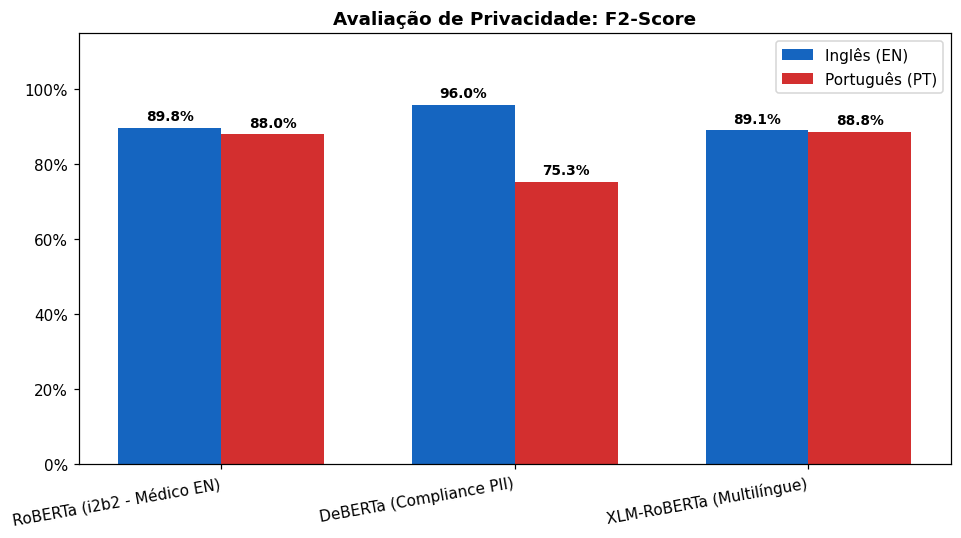

In [ ]:
# converte a lista de dicionários final em um dataframe do pandas
df = pd.DataFrame(resultados)
display_df = df.copy()

#estrutura as colunas de estatística para aparecerem amigavelmente com duas casas decimais e sinal de porcentagem
for col in ["Precision", "Recall", "F2"]: display_df[col] = display_df[col].map("{:.2%}".format)
display_df["Tempo (s)"] = display_df["Tempo (s)"].map("{:.2f}s".format)

print(display_df.to_string(index=False))

# prepara a janela e configura o eixo matplotlib
fig, ax = plt.subplots(figsize=(9, 5), dpi=110)
x = np.arange(len(detectores))
w = 0.35 #largura das barras visuais

# isola os eixos cartesianos com o dado específico do f2 em inglês e português
f2_en = df[df["Idioma"] == "EN"]["F2"].values
f2_pt = df[df["Idioma"] == "PT"]["F2"].values

#plota as barras pareadas para comparação direta entre os dois contextos linguísticos
ax.bar(x - w/2, f2_en, w, label='Inglês (EN)', color='#1565C0')
ax.bar(x + w/2, f2_pt, w, label='Português (PT)', color='#D32F2F')

#ajusta o design estético, titulação e limites de y para evitar poluição no topo
ax.set_title('Avaliação de Privacidade: F2-Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(detectores.keys(), rotation=10, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()

#loop para escolher o topo das barras e desenhar as marcações estatísticas em texto
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

#finaliza a plotagem e exibe o componente final
plt.tight_layout()
plt.show()

In [ ]:
# função que encapsula a lógica de pegar uma linha aleatória, extrair o gabarito real e aplicar as ias
def demonstrar_amostra_aleatoria(dataset, idioma_nome):
    print(f" AMOSTRA ALEATÓRIA: {idioma_nome.upper()} \n")

    # sorteia um item aleatório do dataset para não viciarmos na primeira linha
    item = random.choice(dataset)
    texto_original = item['source_text']

    print("[TEXTO ORIGINAL (Exposto)]")
    print(texto_original)
    print("\n" + "-" * 100 + "\n")

    # extrai as respostas corretas originais que vieram dos criadores do dataset
    mask_raw = item.get('privacy_mask', [])
    if isinstance(mask_raw, str):
        try: mask_raw = json.loads(mask_raw)
        except: mask_raw = []

    # limpa e separa apenas os valores de texto que precisam ser ocultados
    gabarito_valores = {str(ent.get('value', ent)).strip() for ent in mask_raw if str(ent.get('value', ent)).strip()}

    # monta a visualização do gabarito ideal substituindo os dados sensíveis pela tag fixa
    texto_gabarito = texto_original

    # ordena do maior para o menor para evitar que uma palavra curta corte o pedaço de uma palavra longa
    for g in sorted(gabarito_valores, key=len, reverse=True):
        texto_gabarito = re.compile(re.escape(g), re.IGNORECASE).sub("[PII_DETECTION]", texto_gabarito)

    print("[GABARITO ESPERADO (Ocultação Ideal)]")
    print(texto_gabarito)
    print("\n" + "-" * 100 + "\n")

    # prepara o conjunto de gabarito em minúsculo para as contas matemáticas (mesma regra da célula de avaliação)
    gt_set_lower = {g.lower() for g in gabarito_valores}

    # laço que roda a amostra sorteada em todos os modelos carregados na memória
    for nome, det in detectores.items():
        # executa a inteligência no texto
        pred_brutas = det(texto_original)

        # isola as strings que a ia decidiu mascarar para podermos calcular os erros e acertos
        pred_set_lower = {texto_original[e['start']:e['end']].strip().lower() for e in pred_brutas}

        tp, fp, fn = 0, 0, 0

        # algoritmo de conferência (se o gabarito tiver itens)
        if len(gt_set_lower) > 0:
            for gt in gt_set_lower:
                # se o dado sensível real estiver contido no que a ia apagou (ou vice-versa), é acerto (tp)
                if any(gt in p or p in gt for p in pred_set_lower): tp += 1
                else: fn += 1 # vazamento de dado

            # tudo que a ia apagou mas não estava no gabarito vira falso positivo
            fp += sum(1 for p in pred_set_lower if not any(p in gt or gt in p for gt in gt_set_lower))
        else:
            # se não tem pii no gabarito original, tudo que a ia achou é alarme falso
            fp = len(pred_set_lower)

        # equações finais
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f2 = 5 * (prec * rec) / ((4 * prec) + rec) if (prec + rec) > 0 else 0

        # remonta o texto aplicando a formatação de colchetes de trás para frente no índice
        texto_mascarado = texto_original
        for e in sorted(pred_brutas, key=lambda x: x['start'], reverse=True):
            lbl = e.get('entity_group', e.get('entity', e.get('entity_type', e.get('label', 'PII'))))
            lbl = re.sub(r'^[BILU]-', '', lbl) #limpa as tags internas de modelos de linguagem
            texto_mascarado = texto_mascarado[:e['start']] + f"[{lbl}]" + texto_mascarado[e['end']:]

        # estampa o bloco final do modelo
        print(f"MODELO: {nome}")
        print(f"Métricas da Amostra -> TP: {tp} | FP: {fp} | FN: {fn} | F2-Score: {f2:.2%}")
        print(f"TEXTO MASCARADO:\n{texto_mascarado}")
        print("\n" + "-" * 100 + "\n")

# aciona o motor criado acima para sortear e demonstrar
demonstrar_amostra_aleatoria(amostra_en, "Inglês")
demonstrar_amostra_aleatoria(amostra_pt, "Português")

 AMOSTRA ALEATÓRIA: INGLÊS 

[TEXTO ORIGINAL (Exposto)]
Dear Miss Szewczak Mateska, please review the expense projection for September 15th, 1988 which includes high‑frequency data from Leeds and the projected total of 6035407510149082 for the upcoming quarter.

----------------------------------------------------------------------------------------------------

[GABARITO ESPERADO (Ocultação Ideal)]
Dear [PII_DETECTION] [PII_DETECTION], please review the expense projection for [PII_DETECTION] which includes high‑frequency data from [PII_DETECTION] and the projected total of [PII_DETECTION] for the upcoming quarter.

----------------------------------------------------------------------------------------------------

MODELO: RoBERTa (i2b2 - Médico EN)
Métricas da Amostra -> TP: 4 | FP: 0 | FN: 1 | F2-Score: 83.33%
TEXTO MASCARADO:
Dear Miss [PATIENT][PATIENT] [PATIENT], please review the expense projection for [DATE] [DATE] which includes high‑frequency data from [LOC] and the projected

## 5. Cenário de Aplicação Real: Validação com Mesclagem de Spans (*Entity Aggregation*) e Correspondência Rigorosa

Submetemos o pipeline a um documento com estrutura e semântica reais do mercado automotivo: um contrato padrão de compra e venda de veículos, contendo dados do vendedor (Pessoa Jurídica), do comprador (Pessoa Física) e do bem negociado.

### O Desafio da Tokenização vs. O Rigor da LGPD
No mundo real e jurídico da privacidade de dados, um mascaramento parcial (ex: ocultar apenas os 5 primeiros dígitos de um CPF) é um fracasso crítico. Se o dado sensível permanece parcialmente inteligível ou passível de reengenharia, configura-se um vazamento integral.

Por outro lado, modelos baseados em arquiteturas *Transformer* (como RoBERTa e DeBERTa) utilizam tokenizadores de sub-palavras. Isso significa que palavras incomuns, como nomes próprios, são frequentemente "fatiadas" pelo modelo (ex: "GARDIANO" vira `GAR` + `DI` + `ANO`). Avaliar essas predições fragmentadas de forma estrita e isolada resulta em penalizações injustas, onde o modelo oculta a informação perfeitamente na prática, mas recebe nota zero na métrica matemática.

Para equilibrar a justiça arquitetural do modelo com o rigor exigido pela conformidade em privacidade, implementamos uma validação por Mesclagem de Tokens (*Span Merging*) seguida de Match Rigoroso:

* Aglutinação Dinâmica: A função `mesclar_entidades` identifica tokens previstos que estejam adjacentes ou separados apenas por espaços e pontuações, unindo-os em uma única entidade contígua (reconstruindo o dado mascarado em sua totalidade).
* Limpeza de Ruído: A função `strip_punct` remove agressivamente pontuações, traços, barras, espaços e capitalizações de caixa (`.lower()`) do texto aglutinado para uma comparação limpa.
* Tolerância Zero a Vazamentos Parciais: Um acerto só é computado como Verdadeiro Positivo (TP) se a *string aglutinada* corresponder exatamente e na totalidade à entidade presente no gabarito. Se o modelo aglutinar apenas metade de um CPF, a string resultante não baterá com o gabarito, transformando-a instantaneamente em um Falso Negativo (FN) penalizado no F2-Score local.

Essa abordagem simula com precisão o comportamento de uma auditoria rigorosa em uma esteira de automação comercial: avalia-se o resultado final da ocultação no documento, penalizando pesadamente o modelo caso qualquer rastro da informação sensível original permaneça inteligível.

In [ ]:
contrato = (
    "VENDEDOR: LEONN MOTOS LTDA, pessoa jurídica de direito privado, inscrita "
    "no CNPJ n° 28.878.077/0001-88, sediada na Av. Presidente Kennedy, 619, "
    "Boqueirão, Praia Grande/SP, neste ato representada por seu representative "
    "legal, Sr. LEONN GARDIANO.\n\n"
    "COMPRADOR: AMANDO BATISTA, brasileiro(a), portador(a) da cédula de identidade "
    "RG n° 555555555, inscrito(a) no CPF sob o n° 444.444.444-44, "
    "com data de nascimento 19/12/1999, telefone (13) 95677-8889, email amandobatista@gmail.com "
    "residente Av. Paris, N 658, Canto do Forte, Praia Grande/SP, CEP: 11700-260\n\n"
    "Cláusula 1. O veículo HONDA / CB 500X, ano 2022/2022, cor PRATA, "
    "PLACA GAX8G67, RENAVAM 01294890856, CHASSI 9C2PC4920NR002759."
)

gabarito = {
    "leonn motos ltda", "leonn gardiano", "amando batista", "28.878.077/0001-88",
    "555555555", "444.444.444-44", "19/12/1999", "(13) 95677-8889", "amandobatista@gmail.com",
    "av. presidente kennedy, 619, boqueirão, praia grande/sp", "11700-260",
    "av. paris, n 658, canto do forte, praia grande/sp",
    "gax8g67", "01294890856", "9c2pc4920nr002759"
}

#função de apoio que remove pontuações cruas (\W+ remove espaços e traços) e converte para minúsculo
def strip_punct(text):
    return re.sub(r'\W+', '', text).lower()

# o algoritmo principal responsável por unir recortes vizinhos de detecção do transformer
def mesclar_entidades(entidades, texto):
    if not entidades:
        return []

    #ordena todas as previsões na ordem exata de aparição cronológica no texto
    ordenadas = sorted(entidades, key=lambda x: x['start'])
    mescladas = [ordenadas[0].copy()]

    #itera previsões e avalia a distância textual de uma predição até a próxima da lista
    for e in ordenadas[1:]:
        ultimo = mescladas[-1]

        #isola a palavra/caracteres que estão no vão central separando a última predição e a atual
        gap_text = texto[ultimo['end']:e['start']]

        # se após aplicarmos nossa remoção de pontuações esse vão se tornar completamente vazio...
        # isso atesta que as previsões formam juntas na verdade a mesma entidade. expandimos os índices
        if strip_punct(gap_text) == "":
            ultimo['end'] = max(ultimo['end'], e['end'])
        else:
            mescladas.append(e.copy())

    return mescladas

#laço que submete o contrato às três inteligências avaliadas previamente
for nome, det in detectores.items():
    entidades_brutas = det(contrato)

    #processa as quebras estruturais usando o motor desenvolvido acima
    entidades_mescladas = mesclar_entidades(entidades_brutas, contrato)

    # reestrutura as previsões consolidadas já com a higiene gramatical aplicada
    pred_set = {strip_punct(contrato[e['start']:e['end']]) for e in entidades_mescladas}

    #bate cada predição limpa com nosso dicionário gabarito padrão estrito
    acertos = [g for g in gabarito if strip_punct(g) in pred_set]
    vazamentos = [g for g in gabarito if g not in acertos]

    # contadores diretos de erro e acerto real no texto em execução
    tp = len(acertos)
    fn = len(vazamentos)

    fp = max(0, len(pred_set) - tp)
    f2 = (5 * tp) / ((5 * tp) + (4 * fn) + fp) if (tp + fn + fp) > 0 else 0

    print(f"\n[{nome}]")
    print(f" Acertos (TP): {tp} | Vazamentos (FN): {fn} | Mascaramento Inútil (FP): {fp}")
    print(f" F2-Score: {f2:.2%}")


[RoBERTa (i2b2 - Médico EN)]
 Acertos (TP): 5 | Vazamentos (FN): 10 | Mascaramento Inútil (FP): 15
 F2-Score: 31.25%

[DeBERTa (Compliance PII)]
 Acertos (TP): 11 | Vazamentos (FN): 4 | Mascaramento Inútil (FP): 6
 F2-Score: 71.43%

[XLM-RoBERTa (Multilíngue)]
 Acertos (TP): 14 | Vazamentos (FN): 1 | Mascaramento Inútil (FP): 1
 F2-Score: 93.33%


In [ ]:
print(f"[TEXTO ORIGINAL (Exposto)]\n{contrato}\n")
print("-" * 100)

#monta o que deveria ser a resolução correta operando substituições fixas de regex
texto_gabarito = contrato
for g in sorted(gabarito, key=len, reverse=True):
    texto_gabarito = re.compile(re.escape(g), re.IGNORECASE).sub("[PII_DETECTION]", texto_gabarito)

print(f"[GABARITO (Ocultação Ideal)]\n{texto_gabarito}\n")
print("=" * 100)

# rotina que mapeia a string original do contrato, acha o início e o fim exato da predição da ia
#recorta os dados no meio e costura de volta colocando os colchetes com a categoria detectada
for nome, det in detectores.items():
    entidades = det(contrato)
    texto_mascarado = contrato

    # substituições devem ser injetadas de trás pra frente (reverse) no índice de strings
    #do contrário o tamanho da string mudaria ao inserir novas máscaras e os índices de limite posteriores quebrariam
    for e in sorted(entidades, key=lambda x: x['start'], reverse=True):
        lbl = e.get('entity_group', e.get('entity', e.get('entity_type', e.get('label', 'PII'))))
        lbl = re.sub(r'^[BILU]-', '', lbl)
        texto_mascarado = texto_mascarado[:e['start']] + f"[{lbl}]" + texto_mascarado[e['end']:]

    print(f"MODELO: {nome}")
    print(f"TEXTO MASCARADO:\n{texto_mascarado}\n")

[TEXTO ORIGINAL (Exposto)]
VENDEDOR: LEONN MOTOS LTDA, pessoa jurídica de direito privado, inscrita no CNPJ n° 28.878.077/0001-88, sediada na Av. Presidente Kennedy, 619, Boqueirão, Praia Grande/SP, neste ato representada por seu representante legal, Sr. LEONN GARDIANO.

COMPRADOR: AMANDO BATISTA, brasileiro(a), portador(a) da cédula de identidade RG n° 555555555, inscrito(a) no CPF sob o n° 444.444.444-44, com data de nascimento 19/12/1999, telefone (13) 95677-8889, email amandobatista@gmail.com residente Av. Paris, N 658, Canto do Forte, Praia Grande/SP, CEP: 11700-260

Cláusula 1. O veículo HONDA / CB 500X, ano 2022/2022, cor PRATA, PLACA GAX8G67, RENAVAM 01294890856, CHASSI 9C2PC4920NR002759.

----------------------------------------------------------------------------------------------------
[GABARITO (Ocultação Ideal)]
VENDEDOR: [PII_DETECTION], pessoa jurídica de direito privado, inscrita no CNPJ n° [PII_DETECTION], sediada na [PII_DETECTION], neste ato representada por seu repr

## 6. Para Concluir: Arquitetura de Ensemble Híbrido

Após avaliarmos rigorosamente os modelos baseados puramente em NLP por meio das métricas, confirmamos que, de forma isolada, não asseguram a blindagem completa em elementos únicos do formato burocrático e veicular brasileiro (exemplo: estrutura restrita matemática de Placas ou Renavam).

A Lógica Operacional da Fusão (Ensemble Híbrido):
Nesta célula criamos a solução final que age de modo compensatório utilizando Interval Merging.
1. Varredura Semântica: O processamento percorre a rotina no XLM-RoBERTa (O melhor e mais consistente modelo até então) focando puramente em extrações semânticas que carecem de interpretação de contexto que apenas uma IA possui (Exemplo: Distinguir a diferença entre um logradouro corporativo ou o nome fantasia da companhia).
2. O Escudo Determinístico Nacional: O texto percorre simultaneamente um avaliador customizado construído apenas de expressões regulares robustas (Regex) construído para atacar impiedosamente metadados imutáveis e formais (CPFs, Renavams, CEPs, E-mails).
3. Fusão Linpa: Um algoritmo nativo confronta os dois vetores. Se a IA e a ferramenta Regex marcavam posições parecidas tentando anonimizar as mesmas palavras no contrato, o código avalia as extremidades de corte e mantém apenas a abrangência superior da captura, devolvendo um mascaramento perfeito que evita duplicações desnecessárias.

In [ ]:
# definição da nossa engrenagem customizada herdando a classe de interfaces estipuladas
class RegexPIIDetector(BasePIIDetector):
    def __init__(self):
        self._name = "Regex-BR"
        #dicionário base com expressões regulares mapeando os maiores identificadores para a regra de negócio
        self.patterns = {
            "CPF": r"\b\d{3}\.?\d{3}\.?\d{3}-?\\d{2}\b",
            "CNPJ": r"\b\d{2}\.?\d{3}\.?\d{3}/?\d{4}-?\\d{2}\b",
            "CEP": r"\b\d{5}-?\\d{3}\b",
            "TELEFONE": r"\b(?:\(?\d{2}\)?\s?)?\d{4,5}-?\\d{4}\b",
            "EMAIL": r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b",
            "PLACA": r"\b[A-Z]{3}-?[0-9][A-Z0-9][0-9]{2}\b",
            "RENAVAM": r"\b\d{9,11}\b",
            "CHASSI": r"\b[A-HJ-NPR-Z0-9]{17}\b"
        }

    @property
    def name(self) -> str: return self._name

    # método que imita a ia. procura os patterns injetados acima, e empacota no mesmo formato dicionário do hugging face
    def __call__(self, text: str) -> List[Dict[str, Any]]:
        entities = []
        for label, pattern in self.patterns.items():
            for match in re.finditer(pattern, text, re.IGNORECASE):
                entities.append({"entity_group": label, "start": match.start(), "end": match.end(), "score": 1.0})
        return sorted(entities, key=lambda x: x['start'])


#motor central para unir as duas soluções independentes criadas acima
class EnsemblePIIDetector(BasePIIDetector):
    def __init__(self, nlp_detector: BasePIIDetector, regex_detector: BasePIIDetector):
        self._name = f"Ensemble Híbrido ({nlp_detector.name} + Regex)"
        self.nlp = nlp_detector
        self.regex = regex_detector

    @property
    def name(self) -> str: return self._name

    # algoritmo lógico de agrupamento cruzado (cross-merging)
    def __call__(self, text: str) -> List[Dict[str, Any]]:
        pred_nlp = self.nlp(text)
        pred_regex = self.regex(text)

        #une e alinha cronologicamente ambos as execuções
        todas_entidades = sorted(pred_nlp + pred_regex, key=lambda x: x['start'])

        entidades_mescladas = []
        for e in todas_entidades:
            #se a predição nova entra no raio/limites de margem capturados pela predição anterior...
            if entidades_mescladas and e['start'] <= entidades_mescladas[-1]['end']:
                # significa que as detecções tentaram marcar a mesma coisa. o motor mantém as margens mais amplas possíveis
                entidades_mescladas[-1]['end'] = max(entidades_mescladas[-1]['end'], e['end'])
            else:
                #caso contrário, insere a detecção na listagem mestra inalterada
                entidades_mescladas.append(dict(e))

        return entidades_mescladas

# instancia do nlp selecionado e do regexbr customizado, fornecidos na declaração mestre do ensemble
xlm_multilingue = detectores["XLM-RoBERTa (Multilíngue)"]
regex_nacional = RegexPIIDetector()
ensemble = EnsemblePIIDetector(xlm_multilingue, regex_nacional)

#aplica o cálculo definitivo
entidades = ensemble(contrato)
pred_set = {strip_punct(contrato[e['start']:e['end']]) for e in entidades if contrato[e['start']:e['end']].strip()}

acertos = [g for g in gabarito if strip_punct(g) in pred_set]
vazamentos = [g for g in gabarito if g not in acertos]

tp, fn = len(acertos), len(vazamentos)
fp = max(0, len(pred_set) - tp)
f2 = (5 * tp) / ((5 * tp) + (4 * fn) + fp) if (tp + fn + fp) > 0 else 0

print(f"\n[{ensemble.name}]")
print(f"Acertos Perfeitos (TP)  : {tp}")
print(f"Mascarado Errado (FP)   : {fp}")
print(f"VAZAMENTOS CRÍTICOS (FN): {fn}")
print(f"F2-Score Strict Match   : {f2:.2%}")


[Ensemble Híbrido (XLM-RoBERTa (Multilíngue) + Regex)]
Acertos Perfeitos (TP)  : 15
Mascarado Errado (FP)   : 1
VAZAMENTOS CRÍTICOS (FN): 0
F2-Score Strict Match   : 98.68%


In [ ]:
print(f"[TEXTO ORIGINAL (Exposto)]\n{contrato}\n")
print("-" * 100)

#mesma lógica ilustrativa construída previamente visando embasar a leitura
texto_gabarito = contrato
for g in sorted(gabarito, key=len, reverse=True):
    texto_gabarito = re.compile(re.escape(g), re.IGNORECASE).sub("[PII_DETECTION]", texto_gabarito)

print(f"[GABARITO ESPERADO (Ocultação Ideal)]\n{texto_gabarito}\n")
print("-" * 100)

entidades_ensemble = ensemble(contrato)
texto_mascarado_ensemble = contrato

# desconstrói o documento cortando as palavras cruciais indicadas pelo modelo ensemble unificado
for e in sorted(entidades_ensemble, key=lambda x: x['start'], reverse=True):
    lbl = e.get('entity_group', e.get('label', 'PII'))
    lbl = re.sub(r'^[BILU]-', '', lbl)
    texto_mascarado_ensemble = texto_mascarado_ensemble[:e['start']] + f"[{lbl}]" + texto_mascarado_ensemble[e['end']:]

print(f"MODELO: {ensemble.name}")
print(f"TEXTO MASCARADO PELO ENSEMBLE:\\n{texto_mascarado_ensemble}\\n")

[TEXTO ORIGINAL (Exposto)]
VENDEDOR: LEONN MOTOS LTDA, pessoa jurídica de direito privado, inscrita no CNPJ n° 28.878.077/0001-88, sediada na Av. Presidente Kennedy, 619, Boqueirão, Praia Grande/SP, neste ato representada por seu representante legal, Sr. LEONN GARDIANO.

COMPRADOR: AMANDO BATISTA, brasileiro(a), portador(a) da cédula de identidade RG n° 555555555, inscrito(a) no CPF sob o n° 444.444.444-44, com data de nascimento 19/12/1999, telefone (13) 95677-8889, email amandobatista@gmail.com residente Av. Paris, N 658, Canto do Forte, Praia Grande/SP, CEP: 11700-260

Cláusula 1. O veículo HONDA / CB 500X, ano 2022/2022, cor PRATA, PLACA GAX8G67, RENAVAM 01294890856, CHASSI 9C2PC4920NR002759.

----------------------------------------------------------------------------------------------------
[GABARITO ESPERADO (Ocultação Ideal)]
VENDEDOR: [PII_DETECTION], pessoa jurídica de direito privado, inscrita no CNPJ n° [PII_DETECTION], sediada na [PII_DETECTION], neste ato representada por